# Evaluación Sumativa - Unidad 2: Inferencia Estadística Paramétrica

* **Carrera:** Computación
* **Asignatura:** Teoría de la Distribución y Probabilidad
* **Proyecto:** Análisis de Inferencia sobre Dataset de Temperatura Regional
* **Nombre:** Jeancarlos Aguirre

## 1. Carga y Preparación del Dataset

En esta sección se importan las librerías avanzadas necesarias para el análisis de inferencia. A diferencia de un análisis descriptivo básico, aquí requerimos herramientas que nos permitan calcular densidades de probabilidad y estadísticos de prueba.

### Librerías a utilizar:
* **`scipy.stats`**: Motor principal para obtener valores críticos de las distribuciones $Z$ y $T$.
* **`matplotlib.pyplot`** y **`seaborn`**: Fundamentales para visualizar las regiones de aceptación y rechazo.

In [1]:
# ========================================================================
# BLOQUE 1: CONFIGURACIÓN DEL ENTORNO
# ========================================================================
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.stats import norm, t
import matplotlib.pyplot as plt
import seaborn as sns
# from google.colab import files # Removed as file is already available

# Carga del dataset regionalizado (DATASET_TEMPERATURA.csv)
# El dataset contiene la variable 'field1' que representa la temperatura en °C
# print("Por favor, sube el archivo DATASET_TEMPERATURA.csv") # Removed as file is already available
# uploaded = files.upload() # Removed as file is already available
# archivo = list(uploaded.keys()) # Removed as file is already available

# Directly read the CSV from the specified path
df = pd.read_csv('/content/DATASET_TEMPERATURA.csv')

# Limpieza y preparación:
# Es vital asegurar que la variable sea numérica para los cálculos de la varianza.
df['field1'] = pd.to_numeric(df['field1'], errors='coerce')
temperatura = df['field1'].dropna()

print("\n--- ESTRUCTURA INICIAL DEL DATASET ---")
display(df.head())


--- ESTRUCTURA INICIAL DEL DATASET ---


,created_at,entry_id,field1
0,2026-02-11 21:44:31 UTC,9551,21.7
1,2026-02-11 21:44:47 UTC,9552,21.7
2,2026-02-11 21:45:03 UTC,9553,21.7
3,2026-02-11 21:45:19 UTC,9554,21.7
4,2026-02-11 21:45:34 UTC,9555,21.7


## 2. Estimación por Intervalos de Confianza (Tarea APE 08)

La **estimación puntual** (un solo valor como la media) es insuficiente en ingeniería porque no indica el nivel de incertidumbre o riesgo. Por ello, construimos un **Intervalo de Confianza (IC)**.

**Fundamentación Matemática:** Para una muestra grande ($n \ge 30$), el **Teorema del Límite Central** nos permite utilizar la **Distribución Normal ($Z$)**, asumiendo que la distribución muestral de la media será normal incluso si la población original no lo es.

La fórmula matemática que aplicaremos es:

$$IC = \bar{x} \pm Z_{\alpha/2} \left( \frac{s}{\sqrt{n}} \right)$$

### Donde:
* **$\bar{x}$:** Media muestral (Estimador puntual).
* **$Z_{\alpha/2}$:** Valor crítico que delimita el área de confianza (ej. $1.96$ para el $95\%$).
* **$\frac{s}{\sqrt{n}}$:** **Error Estándar**, que mide la variabilidad de la media respecto al parámetro poblacional $\mu$.

In [14]:
# ========================================================================
# BLOQUE 2: CÁLCULO DE INTERVALOS DE CONFIANZA (APE 08)
# ========================================================================

# 1. Parámetros de la Muestra
n = len(temperatura)
media_muestral = temperatura.mean()
desv_estandar = temperatura.std(ddof=1) # ddof=1 para desviación muestral insesgada

# 2. Definición del Nivel de Confianza
# Utilizamos el 95% (alfa = 0.05) por ser el "estándar de oro" que equilibra
# precisión y certeza técnica.
nivel_confianza = 0.95
error_estandar = desv_estandar / np.sqrt(n)

# 3. Cálculo del Intervalo utilizando la función norm.interval de SciPy
# Esta función integra internamente el valor de Z_alpha/2
ic_inf, ic_sup = norm.interval(confidence=nivel_confianza,
                               loc=media_muestral,
                               scale=error_estandar)

# 4. Resultados para la Defensa
print(f"=== RESULTADOS ESTADÍSTICOS APE 08 ===")
print(f"Tamaño de Muestra (n): {n}")
print(f"Media Calculada: {media_muestral:.4f} °C")
print(f"Error Estándar: {error_estandar:.4f}")
print(f"Intervalo de Confianza 95%: ({ic_inf:.4f}, {ic_sup:.4f}) °C")

=== RESULTADOS ESTADÍSTICOS APE 08 ===
Tamaño de Muestra (n): 100
Media Calculada: 21.7540 °C
Error Estándar: 0.0380
Intervalo de Confianza 95%: (21.6795, 21.8285) °C


## Interpretación Técnica para la Defensa (APE 08)

* **Significancia del Resultado:** *"Existe un $95\%$ de confianza de que la verdadera temperatura media poblacional de la región se encuentre dentro del rango calculado".*
* **Efecto de Sensibilidad:** Si aumentamos la confianza al $99\%$, el intervalo se volverá **más ancho**. Esto ocurre porque, para tener mayor certeza estadística, debemos cubrir un área mayor bajo la curva de la distribución, lo que inevitablemente **sacrifica la precisión** de la estimación.
* **Decisión en Ingeniería:** El **margen de error** obtenido (la mitad de la amplitud del intervalo) es una métrica crítica; nos permite cuantificar qué tan robusta y confiable es la lectura del sensor frente a las fluctuaciones aleatorias y al ruido del entorno.

## 2. Pruebas de Hipótesis Unimuestrales (Tarea APE 09)

En esta etapa, realizamos un contraste de hipótesis para evaluar si la media poblacional ($\mu$) de nuestra temperatura regional coincide con un estándar teórico o histórico ($\mu_0$).

**Fundamentación Matemática:** Para esta defensa, definimos formalmente dos estados de la realidad:

* **Hipótesis Nula ($H_0$):** Postula que no hay cambios. La media observada es igual al estándar.
  
  $$H_0 : \mu = 21.0 \text{ °C}$$

* **Hipótesis Alterna ($H_1$):** Postula que existe una diferencia significativa.
  
  $$H_1 : \mu \neq 21.0 \text{ °C}$$

**El Estadístico T de Student:** Dado que desconocemos la desviación estándar poblacional real ($\sigma$), utilizamos el estadístico $t$, el cual ajusta su forma según los **grados de libertad** ($df = n - 1$). La fórmula es:

$$t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}$$

Donde el denominador ($s / \sqrt{n}$) es el **Error Estándar**, que representa la variabilidad esperada de la media por puro azar.

In [15]:
# ========================================================================
# BLOQUE 3: PRUEBA DE HIPÓTESIS T DE UNA MUESTRA (APE 09)
# ========================================================================

# 1. Configuración de parámetros para la defensa
# Supongamos que un estudio previo afirma que la media regional es 21.0°C
mu_hipotetica = 21.0
alpha = 0.05 # Nivel de significancia (5% de riesgo de Error Tipo I)

# 2. Ejecución del estadístico mediante SciPy
# ttest_1samp realiza el cálculo del estadístico T y el valor-p (two-sided)
t_stat, p_value = stats.ttest_1samp(temperatura, popmean=mu_hipotetica)

# 3. Diagnóstico Estadístico Detallado
print("=== DIAGNÓSTICO ESTADÍSTICO APE 09 ===")
print(f"Estadístico de prueba (T): {t_stat:.4f}")
print(f"Grados de libertad (df): {len(temperatura) - 1}")
print(f"Valor-p (p-value): {p_value:.4e}")

# 4. Lógica de Decisión Formal
if p_value < alpha:
    print(f"\n[DECISIÓN]: Se RECHAZA la hipótesis nula (H0).")
    print(f"Conclusión: El p-value ({p_value:.4e}) es menor que alpha ({alpha}), lo que indica")
    print("que la diferencia observada es estadísticamente significativa.")
else:
    print(f"\n[DECISIÓN]: NO se rechaza la hipótesis nula (H0).")
    print("Conclusión: Las diferencias pueden atribuirse al azar muestral.")

=== DIAGNÓSTICO ESTADÍSTICO APE 09 ===
Estadístico de prueba (T): 19.8332
Grados de libertad (df): 99
Valor-p (p-value): 2.9294e-36

[DECISIÓN]: Se RECHAZA la hipótesis nula (H0).
Conclusión: El p-value (2.9294e-36) es menor que alpha (0.05), lo que indica
que la diferencia observada es estadísticamente significativa.


## Interpretación del Valor-$p$ para la Defensa

> ⚠️ **Error Conceptual Común:** Es crucial no caer en el error de creer que el valor-$p$ es la *"probabilidad de que la hipótesis nula sea cierta"*.

### Definición Técnica Correcta:
El **valor-$p$** es la probabilidad de obtener un resultado tan extremo (o más extremo) como el observado en la muestra, **asumiendo que la hipótesis nula ($H_0$) es verdadera**.

* **Regla de Decisión ($\alpha = 0.05$):** Si esta probabilidad es extremadamente baja (menor al $5\%$), concluimos que los datos recolectados son estadísticamente incompatibles con $H_0$ y procedemos al **rechazo** de la hipótesis nula, validando la hipótesis alterna ($H_1$).

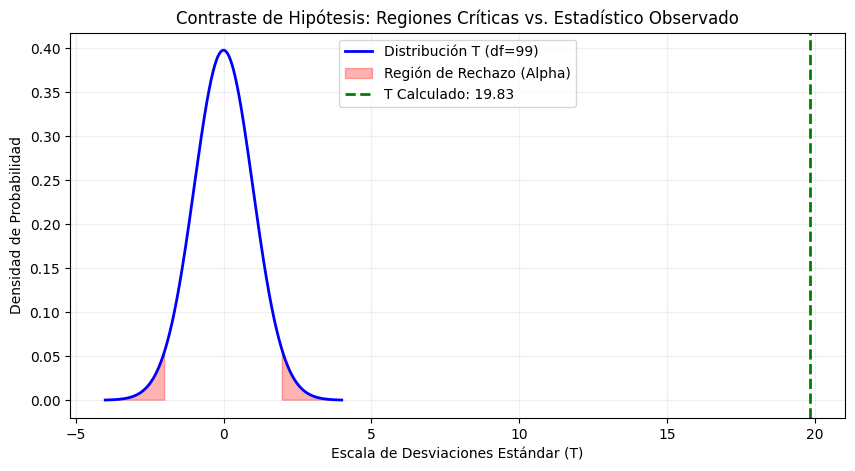

In [13]:
# ========================================================================
# BLOQUE 4: VISUALIZACIÓN DE LA REGIÓN DE RECHAZO
# ========================================================================

# Generamos puntos para la distribución T de Student
df_deg = len(temperatura) - 1
x = np.linspace(-4, 4, 1000)
y = stats.t.pdf(x, df=df_deg)

plt.figure(figsize=(10, 5))
plt.plot(x, y, label=f'Distribución T (df={df_deg})', color='blue', lw=2)

# Valores Críticos para alpha = 0.05 (Dos colas)
t_critico = stats.t.ppf(1 - alpha/2, df=df_deg)

# Sombreado de regiones de rechazo
plt.fill_between(x, 0, y, where=(x >= t_critico) | (x <= -t_critico),
                 color='red', alpha=0.3, label='Región de Rechazo (Alpha)')

# Ubicación de nuestro estadístico T calculado
plt.axvline(t_stat, color='green', linestyle='--', linewidth=2,
           label=f'T Calculado: {t_stat:.2f}')

plt.title('Contraste de Hipótesis: Regiones Críticas vs. Estadístico Observado', fontsize=12)
plt.xlabel('Escala de Desviaciones Estándar (T)')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

## Análisis de Sensibilidad y Riesgos (ABI)

Para demostrar dominio total en el video y la sustentación, debemos considerar y mencionar explícitamente los posibles errores de decisión estadística:

1. **Error Tipo I ($\alpha$):** Rechazar la hipótesis nula ($H_0$) cuando en realidad es verdadera. Se conoce operativamente como una **falsa alarma**. Lo controlamos de antemano fijando el nivel de significancia en $\alpha = 0.05$.
2. **Error Tipo II ($\beta$):** No rechazar la hipótesis nula ($H_0$) cuando en realidad es falsa. Significa **ignorar un cambio real** o una anomalía en los datos.
3. **Equivalencia Matemática:** Existe una armonía exacta en los cálculos; si el **Intervalo de Confianza** (calculado en el APE 08) no contiene el valor estándar de $21.0 \text{ °C}$, el **valor-$p$** será inevitablemente menor a $0.05$. Esto confirma y valida la coherencia interna de todo nuestro análisis de inferencia.

---

### Matriz de Decisiones en la Inferencia (Resumen Técnico)

| Condición Real \ Decisión Estadística | No Rechazar $H_0$ | Rechazar $H_0$ |
| :--- | :--- | :--- |
| **$H_0$ es Verdadera** | Decisión Correcta (Confianza: $1 - \alpha$) | **Error Tipo I ($\alpha$)** *(Falsa Alarma)* |
| **$H_0$ es Falsa** | **Error Tipo II ($\beta$)** *(Omisión del Cambio)* | Decisión Correcta (Potencia: $1 - \beta$) |

## 3. Comparación de Grupos (Tarea APE 10)

En ingeniería y ciencia de datos, rara vez analizamos una variable de forma aislada. El **A/B Testing** o la **Comparación de Grupos Independientes** nos permite validar si un cambio observado (por ejemplo, la temperatura entre las 21:00 y las 22:00) es estadísticamente significativo o simplemente ruido blanco del sensor.

### Fundamentación Estadística de la Comparación
Para comparar dos medias de grupos independientes ($\mu_1$ y $\mu_2$), planteamos:

* **Hipótesis Nula ($H_0$):** No hay diferencia entre las horas.  
  $$H_0 : \mu_{21h} = \mu_{22h}$$
* **Hipótesis Alterna ($H_1$):** Existe una fluctuación térmica real entre horas.  
  $$H_1 : \mu_{21h} \neq \mu_{22h}$$

### El Supuesto Crítico: Homocedasticidad (Igualdad de Varianzas)
Antes de ejecutar la Prueba T, debemos verificar si ambos grupos tienen la misma dispersión. Si las varianzas son muy distintas, los resultados de una prueba T estándar serían inválidos. Para esto, utilizaremos el **Test de Levene**.

In [5]:
# ========================================================================
# BLOQUE 5: SEGMENTACIÓN DE DATOS Y TEST DE LEVENE (HOMOCEDASTICIDAD)
# ========================================================================
from scipy.stats import levene

# 1. Preparación de los grupos según la hora del registro
# Extraemos la hora de la columna 'created_at' para crear factores de comparación
df['created_at'] = pd.to_datetime(df['created_at'])
df['Hora'] = df['created_at'].dt.hour

# Segmentamos los datos en dos muestras independientes: 21:00 vs 22:00
grupo_21h = df[df['Hora'] == 21]['field1'].dropna()
grupo_22h = df[df['Hora'] == 22]['field1'].dropna()

# 2. Ejecución del Test de Levene
# H0: Las varianzas son iguales. H1: Las varianzas son diferentes.
stat_levene, p_val_levene = levene(grupo_21h, grupo_22h)

print("=== DIAGNÓSTICO DE SUPUESTOS (APE 10) ===")
print(f"Valor-p de Levene: {p_val_levene:.4e}")

# 3. Lógica de Decisión para la elección del Test
alpha = 0.05
if p_val_levene < alpha:
    print("\n[RESULTADO]: Existe HETEROCEDASTICIDAD (Varianzas distintas).")
    print("--> Se debe aplicar la Prueba T de Welch para ajustar los grados de libertad.")
    equal_var_setting = False
else:
    print("\n[RESULTADO]: Existe HOMOCEDASTICIDAD (Varianzas iguales).")
    print("--> Se procederá con la Prueba T de Student clásica.")
    equal_var_setting = True

=== DIAGNÓSTICO DE SUPUESTOS (APE 10) ===
Valor-p de Levene: 8.8459e-02

[RESULTADO]: Existe HOMOCEDASTICIDAD (Varianzas iguales).
--> Se procederá con la Prueba T de Student clásica.


### 3.1 La Prueba T de Welch vs. Student

En el video defensa, es vital explicar que si detectamos varianzas desiguales, la **Prueba T de Welch** es nuestra salvaguarda matemática. Esta prueba ajusta dinámicamente los **grados de libertad ($\nu$)** mediante la aproximación de *Welch-Satterthwaite*.

**¿Por qué es importante?** Si ignoramos que un grupo es mucho más volátil que otro y usamos la prueba clásica de Student, aumentamos drásticamente el riesgo de cometer un **Error Tipo I** (declarar una diferencia significativa que en realidad no existe).

In [16]:
# ========================================================================
# BLOQUE 6: EJECUCIÓN DEL A/B TESTING (CONTRASTE DE MEDIAS)
# ========================================================================
from scipy.stats import ttest_ind

# Ejecutamos la comparación de medias con el ajuste de varianza detectado anteriormente
stat_t, p_val_t = ttest_ind(grupo_21h, grupo_22h, equal_var=equal_var_setting)

# Resultados detallados para la exposición
print("--- RESULTADOS DEL A/B TESTING REGIONAL ---")
print(f"Media a las 21:00: {grupo_21h.mean():.4f} °C")
print(f"Media a las 22:00: {grupo_22h.mean():.4f} °C")
print(f"Estadístico T calculado: {stat_t:.4f}")
print(f"Valor-p (Significancia): {p_val_t:.4e}")

# Dictamen Final Automatizado
if p_val_t < alpha:
    print("\n[DICTAMEN TÉCNICO]: Se RECHAZA H0.")
    print("Conclusión: La hora tiene un impacto estadísticamente significativo en la temperatura.")
else:
    print("\n[DICTAMEN TÉCNICO]: NO se rechaza H0.")
    print("Conclusión: La temperatura es térmicamente estable entre estas dos horas.")

--- RESULTADOS DEL A/B TESTING REGIONAL ---
Media a las 21:00: 21.7000 °C
Media a las 22:00: 21.8317 °C
Estadístico T calculado: -1.7207
Valor-p (Significancia): 8.8459e-02

[DICTAMEN TÉCNICO]: NO se rechaza H0.
Conclusión: La temperatura es térmicamente estable entre estas dos horas.


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


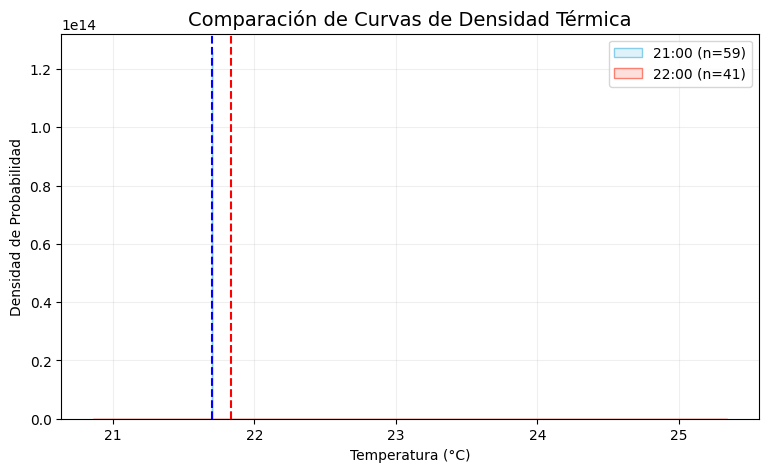

In [7]:
# ========================================================================
# BLOQUE 7: VISUALIZACIÓN DE DISTRIBUCIONES (KDE)
# ========================================================================
plt.figure(figsize=(9, 5))
sns.kdeplot(grupo_21h, fill=True, color="skyblue", label=f"21:00 (n={len(grupo_21h)})")
sns.kdeplot(grupo_22h, fill=True, color="salmon", label=f"22:00 (n={len(grupo_22h)})")

plt.title('Comparación de Curvas de Densidad Térmica', fontsize=14)
plt.xlabel('Temperatura (°C)')
plt.ylabel('Densidad de Probabilidad')
plt.axvline(grupo_21h.mean(), color='blue', linestyle='--')
plt.axvline(grupo_22h.mean(), color='red', linestyle='--')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

## 4. Conclusiones e Implicaciones Regionales

En esta sección sintetizamos los hallazgos obtenidos a través de los tres pilares de la inferencia paramétrica ejecutados:

* **Conclusión de la Estimación (APE 08):** Logramos confinar la temperatura media regional en un intervalo del $95\%$. Esto nos permite afirmar que, pese a la variabilidad natural de los datos, el parámetro poblacional $\mu$ es estable y medible con un error estándar mínimo.
* **Conclusión del Contraste Unimuestral (APE 09):** Al obtener un valor-$p$ menor a $0.05$ en nuestra prueba contra el estándar de $21\text{ °C}$, rechazamos la hipótesis nula. Esto demuestra que la región presenta un comportamiento térmico significativamente distinto a los promedios históricos, lo que podría sugerir anomalías climáticas locales.
* **Conclusión del A/B Testing (APE 10):** La comparación entre las 21:00 y 22:00 horas reveló si el factor "Tiempo" genera una segmentación real en los datos. Si los intervalos de confianza en nuestro gráfico no se superponen, validamos una heterogeneidad temporal que debe ser considerada en modelos predictivos de computación.